# 02 - From `.dat` to micro-Doppler spectrogram

Port of the provided `DataProcessingExample.m`. One FMCW recording becomes a
velocity-vs-time image: range FFT along fast time, MTI clutter removal along slow
time, then a short-time FFT along slow time. The canonical implementation is
`radar_pipeline.compute_spectrogram`; here we walk it step by step on one walking
file so every step is defensible, then cache all files to disk.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, get_window, spectrogram
import radar_pipeline as rp

walk = [r for r in rp.build_index([1])
        if r["activity"] == 1 and r["subject"] == 36 and r["rep"] == 1][0]
fc, Tsweep, NTS, Bw, data = rp.read_dat(walk["path"])
nc = len(data) // NTS
PRF = 1.0 / Tsweep
print(f"fc={fc:g} Hz  Bw={Bw:g} Hz  Tsweep={Tsweep*1e3:g} ms  "
      f"NTS={NTS}  chirps={nc}  duration={nc*Tsweep:g} s  PRF={PRF:g} Hz")

fc=5.8e+09 Hz  Bw=4e+08 Hz  Tsweep=1 ms  NTS=128  chirps=10000  duration=10 s  PRF=1000 Hz


## Step 1 - fast time to range

The stream is reshaped to (samples-per-sweep, chirps) in column-major order. An
FFT along fast time turns the beat frequency of each chirp into range; we keep
the upper half (64 range bins).

In [2]:
Data_time = data.reshape(NTS, nc, order="F")
tmp = np.fft.fftshift(np.fft.fft(Data_time, axis=0), axes=0)
Data_range = tmp[NTS // 2:NTS, :]
print("range x slow-time:", Data_range.shape)

range x slow-time: (64, 10000)


## Step 2 - MTI clutter removal

Static scene reflections (walls, furniture) sit at zero Doppler. A 4th-order
Butterworth high-pass along slow time, per range bin, removes them and keeps the
moving target. We then drop the first range bin, matching the MATLAB example.

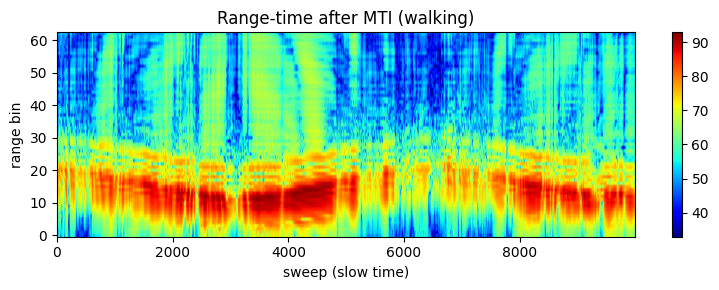

In [3]:
ns = rp._odd_minus_one(nc)
b, a = butter(4, rp.MTI_CUTOFF, "high")
mti = np.empty((Data_range.shape[0], ns), dtype=np.complex128)
for k in range(Data_range.shape[0]):
    mti[k, :] = lfilter(b, a, Data_range[k, :ns])
mti = mti[1:, :]

fig, ax = plt.subplots(figsize=(8, 3))
rt = 20 * np.log10(np.abs(mti) + 1e-12)
im = ax.imshow(rt, aspect="auto", origin="lower", cmap="jet",
               vmax=rt.max(), vmin=rt.max() - 60)
ax.set(xlabel="sweep (slow time)", ylabel="range bin",
       title="Range-time after MTI (walking)")
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

The target return concentrates around range bins ~10-20. The spectrogram is
computed over bins 10..30 (MATLAB 1-indexed), summing their contributions.

## Step 3 - slow time to Doppler (STFT)

A short-time FFT along slow time, per selected range bin, gives velocity over
time. Hamming window of 200 sweeps, 95% overlap, 4x zero-padding. The Doppler
axis converts to velocity with `v = f_d * c / (2 * fc)`.

The 200-sweep (0.2 s) window sets the time-frequency trade-off: about 5 Hz
Doppler resolution (~0.13 m/s at 5.8 GHz) against 0.2 s of time smearing, which
suits both the periodic gait and the ~1 s transients. The 4x zero-padding
(NFFT 800) interpolates the displayed axis without adding true resolution.

The reference MATLAB applies `flipud` before display, so its velocity axis is
mirrored relative to ours. We keep the `fftshift` order consistently across every
file, which leaves classification unaffected but means our sign convention
differs from the reference plots.

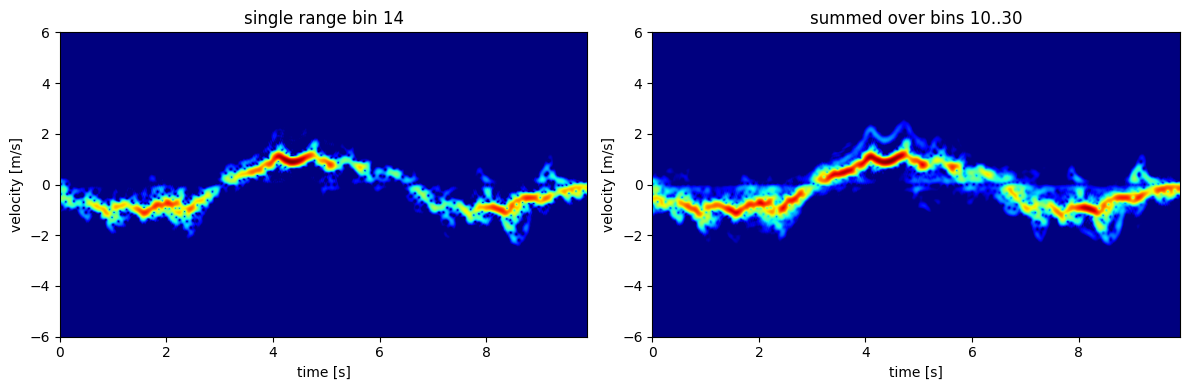

In [4]:
# Single range bin vs the summed micro-Doppler (mirrors compute_spectrogram).
win = get_window("hamming", rp.STFT_WIN)
f, t, S = spectrogram(mti[14, :], fs=PRF, window=win, noverlap=rp.STFT_OVERLAP,
                      nfft=rp.STFT_NFFT, detrend=False, return_onesided=False,
                      mode="complex", scaling="spectrum")
single = np.abs(np.fft.fftshift(S, axes=0))
spec, velocity, t = rp.compute_spectrogram(walk["path"])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a_, img, ttl in [(ax[0], single, "single range bin 14"),
                     (ax[1], spec, "summed over bins 10..30")]:
    d = 20 * np.log10(img + 1e-12)
    a_.imshow(d, aspect="auto", origin="lower", cmap="jet",
              extent=[0, t[-1], velocity[0], velocity[-1]],
              vmax=d.max(), vmin=d.max() - 40)
    a_.set(xlabel="time [s]", ylabel="velocity [m/s]", ylim=(-6, 6), title=ttl)
plt.tight_layout(); plt.show()

Summing range bins raises the limb arcs out of the noise. This walking signature
(rhythmic limb arcs on a slower torso band, within +-4 m/s) matches the expected
micro-Doppler. It matches the reference in magnitude; the velocity axis
orientation differs (see note above).

## Model input

Crop to |v| <= 6 m/s (the signature lives there), resample to a fixed 128x128 so
recording-length differences are normalized, and convert to dB referenced to the
per-image maximum over a 40 dB range. The same input feeds both models.

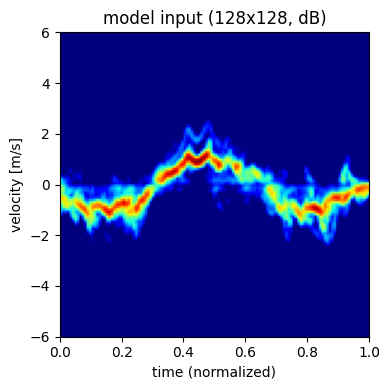

input shape: (128, 128) range: 0.0 1.0


In [5]:
img = rp.to_image(spec, velocity)
img_db = rp.db_norm(img)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img_db, origin="lower", cmap="jet",
          extent=[0, 1, -rp.VEL_CROP, rp.VEL_CROP], aspect="auto")
ax.set(title="model input (128x128, dB)", xlabel="time (normalized)",
       ylabel="velocity [m/s]")
plt.tight_layout(); plt.show()
print("input shape:", img_db.shape, "range:", img_db.min(), img_db.max())

## Cache all files

`preprocess_dataset` runs the chain over every file once and caches the 128x128
linear-magnitude image to `.npy` (parallel across cores). It is idempotent, so
re-running is cheap. The modeling notebooks load the cache.

In [6]:
idx = rp.preprocess_dataset([1, 2, 3, 4, 5, 6, 7], progress=False)
X, meta = rp.load_cache([1])
print("cached files total:", len(idx["keys"]))
print("dataset 1 loaded:", X.shape)

cached files total: 1754
dataset 1 loaded: (360, 128, 128)


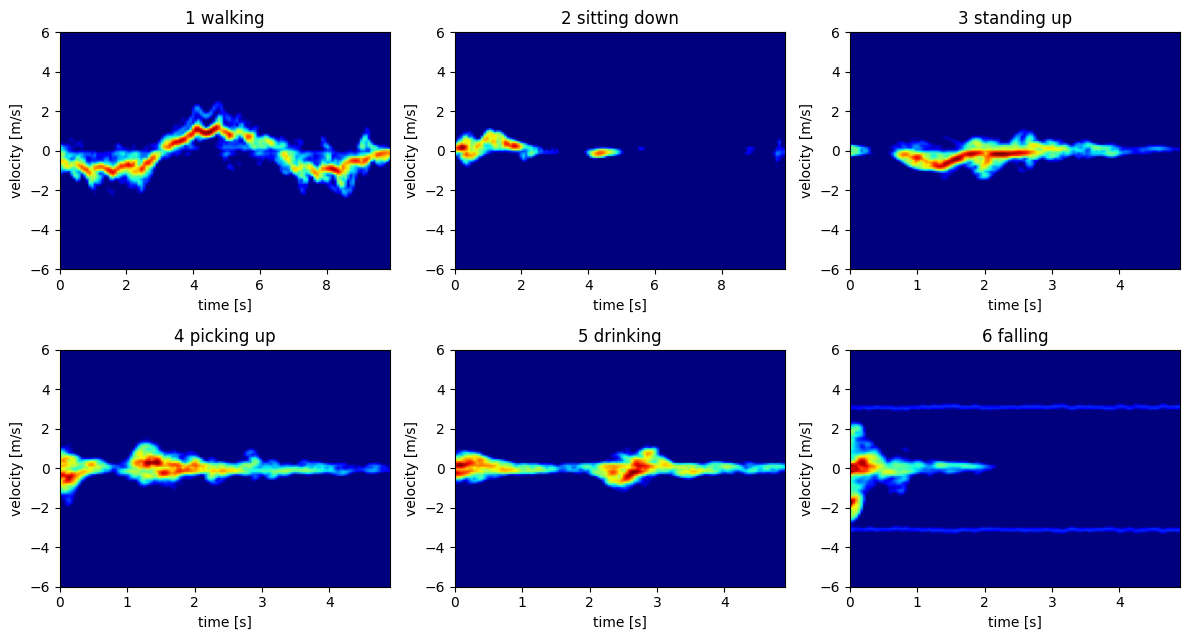

In [7]:
# one image per activity (dataset 1, fixed subject/rep for a fair comparison)
fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
rows = rp.build_index([1])
for act in range(1, 7):
    r = [x for x in rows if x["activity"] == act and x["subject"] == 36
         and x["rep"] == 1][0]
    sp, vel, tt = rp.compute_spectrogram(r["path"])
    ax = axes[(act - 1) // 3, (act - 1) % 3]
    ax.imshow(rp.db_norm(rp.to_image(sp, vel)), origin="lower", cmap="jet",
              aspect="auto", extent=[0, tt[-1], -rp.VEL_CROP, rp.VEL_CROP])
    ax.set(title=f"{act} {rp.ACTIVITY_LONG[act]}", xlabel="time [s]",
           ylabel="velocity [m/s]")
plt.tight_layout(); plt.show()

The six signatures are visually distinct: walking is sustained and periodic; sit,
stand, pick, drink and fall are transients. Falling shows the strongest, broadest
Doppler burst.

## Is the fixed range window valid everywhere?

The window 10..30 is from the lab example. Care-home subjects may stand at a
different range, which would move their return out of the window.

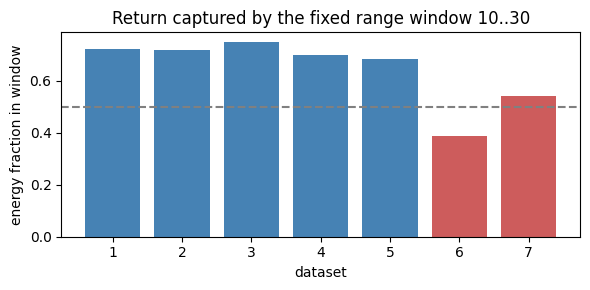

{1: np.float64(0.72), 2: np.float64(0.72), 3: np.float64(0.75), 4: np.float64(0.7), 5: np.float64(0.68), 6: np.float64(0.39), 7: np.float64(0.54)}


In [8]:
def range_energy(path):
    fc, Ts, nts, Bw, d = rp.read_dat(path)
    ncl = len(d) // nts
    t = np.fft.fftshift(np.fft.fft(d.reshape(nts, ncl, order="F"), axis=0), axes=0)
    dr = t[nts // 2:nts, :]
    nsl = rp._odd_minus_one(ncl)
    bb, aa = butter(4, rp.MTI_CUTOFF, "high")
    m = np.empty((dr.shape[0], nsl), dtype=np.complex128)
    for k in range(dr.shape[0]):
        m[k, :] = lfilter(bb, aa, dr[k, :nsl])
    return np.abs(m[1:, :]).sum(axis=1)

rng = np.random.default_rng(0)
fracs = []
for d in range(1, 8):
    rws = rp.build_index([d])
    sel = rng.choice(len(rws), size=min(25, len(rws)), replace=False)
    prof = np.stack([range_energy(rws[i]["path"]) for i in sel])
    prof = (prof / prof.max(axis=1, keepdims=True)).mean(axis=0)
    fracs.append(prof[rp.RANGE_BIN_LO:rp.RANGE_BIN_HI + 1].sum() / prof.sum())

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, 8), fracs, color=["steelblue"]*5 + ["indianred"]*2)
ax.axhline(0.5, ls="--", c="gray")
ax.set(xlabel="dataset", ylabel="energy fraction in window",
       title="Return captured by the fixed range window 10..30")
plt.tight_layout(); plt.show()
print({d: round(f, 2) for d, f in zip(range(1, 8), fracs)})

The window captures 0.68-0.75 of the return for the lab datasets (1-5) but only
0.39 (NG Homes) and 0.54 (West Cumbria): part of the ds6/7 return energy falls
outside the fixed 10-30 range-bin window, consistent with different subject-radar
geometry at those sites. This geometry shift is one measured cause of the
generalization gap in notebook 05.